# Etape 1 — Étude préliminaire

**UE Données complexes — M1 SDSC**  
Données de qualité d'eau 2013, bassin Rhin-Meuse (NAIADES)

**Objectif** : charger et formater les données physico-chimiques, en faire une étude statistique préliminaire, et préparer un jeu de données propre pour le clustering.

## 1. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

os.makedirs('../outputs/tables', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

ANALYSES_CSV = '../data/raw/naiades-RM/Analyses.CSV'
STATIONS_CSV = '../data/raw/naiades-RM/Stations.CSV'

## 2. Chargement et filtrage des données

On ne conserve que les 15 paramètres physico-chimiques demandés dans le sujet.

In [2]:
TARGET_PARAMS = [
    ("Température de l'Eau", "Eau brute", "°C"),
    ("Potentiel en Hydrogène (pH)", "Eau brute","unité pH"),
    ("Oxygène dissous", "Eau brute","mg(O2)/L"),
    ("Conductivité à 25°C", "Eau brute","µS/cm"),
    ("Matières en suspension", "Eau brute","mg/L"),
    ("Turbidité Formazine Néphélométrique", "Eau brute","NFU"),
    ("Carbone Organique", "Phase aqueuse de l'eau (filtrée, centrifugée...)", "mg(C)/L"),
    ("Nitrates", "Phase aqueuse de l'eau (filtrée, centrifugée...)", "mg(NO3)/L"),
    ("Phosphore total", "Eau brute","mg(P)/L"),
    ("Azote Kjeldahl", "Eau brute","mg(N)/L"),
    ("Orthophosphates (PO4)", "Phase aqueuse de l'eau (filtrée, centrifugée...)", "mg(PO4)/L"),
    ("Ammonium", "Phase aqueuse de l'eau (filtrée, centrifugée...)", "mg(NH4)/L"),
    ("Nitrites", "Phase aqueuse de l'eau (filtrée, centrifugée...)", "mg(NO2)/L"),
    ("Demande Biochimique en oxygène en 5 jours (D.B.O.5)", "Eau brute", "mg(O2)/L"),
    ("Demande Chimique en Oxygène (DCO)", "Eau brute", "mg(O2)/L"),
]

PARAM_SHORT = [
    'Température', 'pH', 'O2_dissous', 'Conductivité', 'MES', 'Turbidité',
    'Carbone_org', 'Nitrates', 'Phosphore_total', 'Azote_Kjeldahl',
    'Orthophosphates', 'Ammonium', 'Nitrites', 'DBO5', 'DCO'
]

param_key_to_short = {t: s for t, s in zip(TARGET_PARAMS, PARAM_SHORT)}

print(f'{len(TARGET_PARAMS)} paramètres cibles définis.')

15 paramètres cibles définis.


In [3]:
df_raw = pd.read_csv(
    ANALYSES_CSV,
    sep=';',
    dtype=str,
    na_values='',
    parse_dates=['DatePrel'],
    date_format='%Y-%m-%d',
)

df_raw['RsAna'] = pd.to_numeric(df_raw['RsAna'], errors='coerce')

print(f'Lignes totales : {len(df_raw):,}')
print(f'Stations       : {df_raw["CdStationMesureEauxSurface"].nunique()}')
print(f'Période        : {df_raw["DatePrel"].min()} → {df_raw["DatePrel"].max()}')
df_raw[['CdStationMesureEauxSurface','LbStationMesureEauxSurface',
        'DatePrel','LbLongParamètre','LbFractionAnalysee','SymUniteMesure','RsAna']].head()

Lignes totales : 110,688
Stations       : 298
Période        : 2013-01-07 00:00:00 → 2013-12-23 00:00:00


,CdStationMesureEauxSurface,LbStationMesureEauxSurface,DatePrel,LbLongParamètre,LbFractionAnalysee,SymUniteMesure,RsAna
0,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-01-07,Turbidité Formazine Néphélométrique,Eau brute,NFU,3.0
1,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-01-07,Température de l'Eau,Eau brute,°C,7.0
2,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-01-07,Potentiel en Hydrogène (pH),Eau brute,unité pH,8.2
3,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-01-07,Conductivité à 25°C,Eau brute,µS/cm,384.0
4,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-01-07,Matières en suspension,Eau brute,mg/L,3.6


In [4]:
df_raw['_key'] = list(zip(
    df_raw['LbLongParamètre'],
    df_raw['LbFractionAnalysee'],
    df_raw['SymUniteMesure']
))

target_set = set(TARGET_PARAMS)
df_sel = df_raw[df_raw['_key'].isin(target_set)].copy()
df_sel['param_court'] = df_sel['_key'].map(param_key_to_short)

print(f'Lignes après filtrage : {len(df_sel):,}')
print(f'Paramètres présents   : {df_sel["param_court"].nunique()}')
print(df_sel['param_court'].value_counts().to_string())

Lignes après filtrage : 43,459
Paramètres présents   : 15
param_court
Température        3090
O2_dissous         3090
DBO5               3090
MES                3076
Azote_Kjeldahl     3076
Conductivité       3075
DCO                3075
Phosphore_total    3074
pH                 3067
Carbone_org        3036
Nitrates           2869
Turbidité          2501
Nitrites           2447
Orthophosphates    2447
Ammonium           2446


## 3. Tableau station  date  paramètres

On crée le tableau pivot avec les stations et dates en lignes, les paramètres en colonnes.

In [5]:
df_pivot = df_sel.pivot_table(
    index=['CdStationMesureEauxSurface', 'LbStationMesureEauxSurface', 'DatePrel'],
    columns='param_court',
    values='RsAna',
    aggfunc='mean'
).reset_index()
df_pivot.columns.name = None

cols_meta = ['CdStationMesureEauxSurface', 'LbStationMesureEauxSurface', 'DatePrel']
cols_param = [p for p in PARAM_SHORT if p in df_pivot.columns]
df_pivot = df_pivot[cols_meta + cols_param]

print(f'Tableau station × date : {df_pivot.shape}')
print(f'Stations : {df_pivot["CdStationMesureEauxSurface"].nunique()}')
print(f'Prélèvements (lignes) : {len(df_pivot):,}')
df_pivot.head(8)

Tableau station × date : (3520, 18)
Stations : 298
Prélèvements (lignes) : 3,520


,CdStationMesureEauxSurface,LbStationMesureEauxSurface,DatePrel,Température,pH,O2_dissous,Conductivité,MES,Turbidité,Carbone_org,Nitrates,Phosphore_total,Azote_Kjeldahl,Orthophosphates,Ammonium,Nitrites,DBO5,DCO
0,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-01-07,7.0,8.20,12.4,384.0,3.6,3.00,1.9,7.4,0.02,0.6,0.06,0.07,0.03,3.4,6.0
1,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-02-04,5.9,8.10,12.7,378.0,22.0,15.00,2.2,7.4,0.04,0.5,0.09,0.08,0.03,2.1,8.0
2,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-03-04,5.4,8.30,14.6,420.0,2.4,0.99,1.3,7.8,0.02,0.5,0.04,0.08,0.04,1.8,5.0
3,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-04-02,6.7,8.30,11.8,381.0,4.9,2.50,2.7,8.2,0.07,0.5,0.13,0.05,0.05,1.8,5.0
4,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-04-29,10.5,8.25,11.5,385.0,6.7,3.20,1.9,5.2,0.13,0.5,0.14,0.08,0.03,2.1,9.0
5,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-05-27,12.4,8.30,13.0,339.0,5.1,3.10,1.8,5.3,0.02,0.5,0.05,0.07,0.04,0.8,5.0
6,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-06-24,14.9,7.95,10.0,320.0,11.0,2.90,1.6,4.4,0.02,0.5,0.08,0.06,0.03,1.0,6.0
7,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-07-22,23.9,8.25,8.0,314.0,3.7,2.60,1.7,4.0,0.02,0.5,0.02,0.05,0.04,0.8,6.0


## 4. Statistiques descriptives

### 4.1 Fréquence des paramètres et des stations

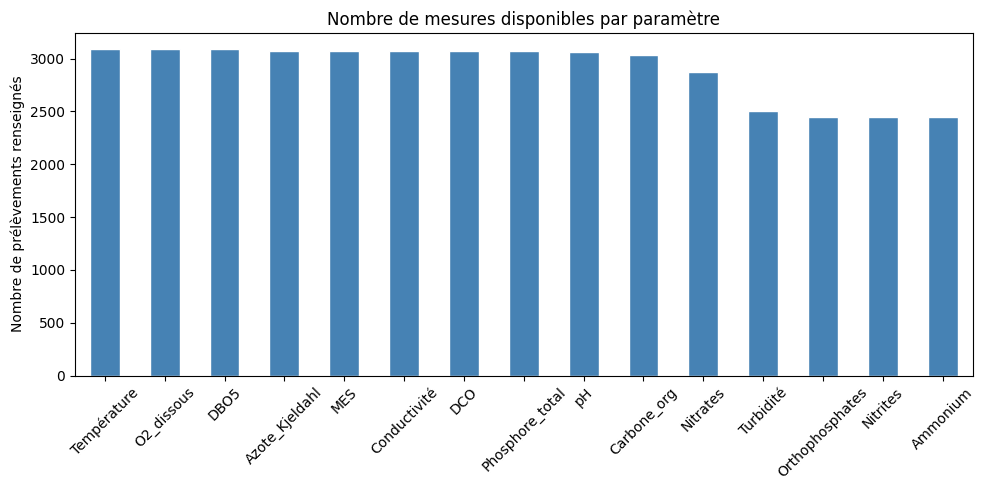

Paramètres les plus fréquents :
Température       3090
O2_dissous        3090
DBO5              3090
Azote_Kjeldahl    3076
MES               3076

Paramètres les moins fréquents :
Nitrates           2869
Turbidité          2501
Orthophosphates    2447
Nitrites           2447
Ammonium           2446


In [6]:
param_counts = df_pivot[cols_param].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
param_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Nombre de mesures disponibles par paramètre')
ax.set_ylabel('Nombre de prélèvements renseignés')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/tp1_param_counts.png', dpi=120)
plt.show()

print('Paramètres les plus fréquents :')
print(param_counts.head(5).to_string())
print('\nParamètres les moins fréquents :')
print(param_counts.tail(5).to_string())

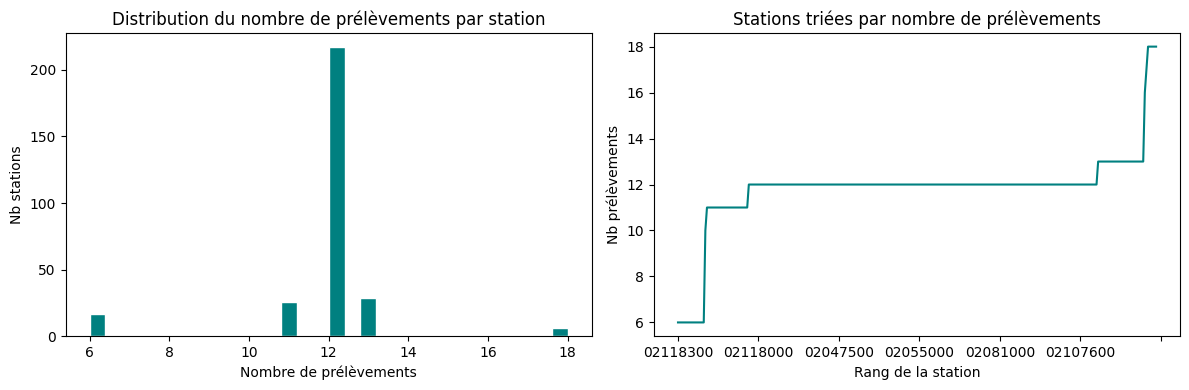

Stations avec ≥ 10 prélèvements : 281
Stations avec < 4 prélèvements  : 0

Statistiques (nb prélèvements/station) :
count    298.0
mean      11.8
std        1.8
min        6.0
25%       12.0
50%       12.0
75%       12.0
max       18.0
dtype: float64


In [7]:
prel_per_station = df_pivot.groupby('CdStationMesureEauxSurface').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
prel_per_station.plot(kind='hist', bins=30, ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Distribution du nombre de prélèvements par station')
axes[0].set_xlabel('Nombre de prélèvements')
axes[0].set_ylabel('Nb stations')

prel_per_station.sort_values().plot(kind='line', ax=axes[1], color='teal')
axes[1].set_title('Stations triées par nombre de prélèvements')
axes[1].set_xlabel('Rang de la station')
axes[1].set_ylabel('Nb prélèvements')

plt.tight_layout()
plt.savefig('../outputs/figures/tp1_prelevements_par_station.png', dpi=120)
plt.show()

print(f'Stations avec ≥ 10 prélèvements : {(prel_per_station >= 10).sum()}')
print(f'Stations avec < 4 prélèvements  : {(prel_per_station < 4).sum()}')
print(f'\nStatistiques (nb prélèvements/station) :')
print(prel_per_station.describe().round(1))

### 4.2 Distribution de 3 paramètres contrastés

On illustre avec trois paramètres aux comportements très différents : **Température** (très fréquente, distribution large), **Nitrates** (liés à l'agriculture) et **Orthophosphates** (moins fréquents, très asymétriques).

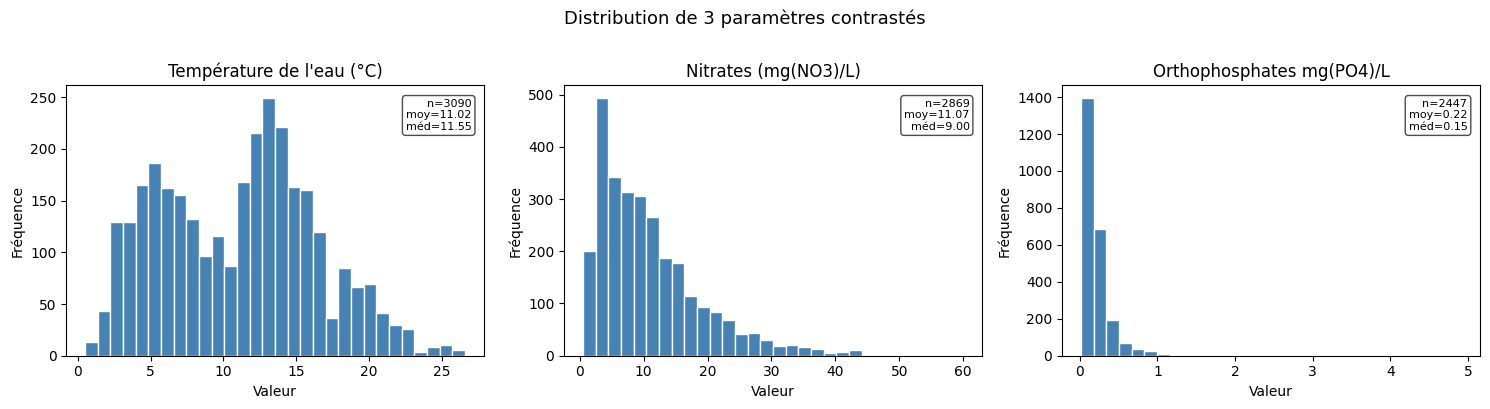

In [8]:
params_illustr = ['Température', 'Nitrates', 'Orthophosphates']
titles = [
    'Température de l\'eau (°C)',
    'Nitrates (mg(NO3)/L)',
    'Orthophosphates mg(PO4)/L'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, param, title in zip(axes, params_illustr, titles):
    data = df_pivot[param].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', density=False)
    ax.set_title(title)
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.text(0.97, 0.95, f'n={len(data)}\nmoy={data.mean():.2f}\nméd={data.median():.2f}',
            transform=ax.transAxes, va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
plt.suptitle('Distribution de 3 paramètres contrastés', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/tp1_distributions_3params.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.3 Statistiques descriptives globales

In [9]:
df_pivot[cols_param].describe().round(3)

,Température,pH,O2_dissous,Conductivité,MES,Turbidité,Carbone_org,Nitrates,Phosphore_total,Azote_Kjeldahl,Orthophosphates,Ammonium,Nitrites,DBO5,DCO
count,3090.000,3067.000,3090.000,3075.000,3076.000,2501.000,3036.000,2869.000,3074.000,3076.000,2447.000,2446.000,2447.000,3090.000,3075.000
mean,11.020,7.875,9.872,539.591,16.365,8.073,3.450,11.066,0.107,0.725,0.216,0.172,0.089,1.754,11.707
std,5.347,0.377,1.971,502.623,31.541,13.227,1.836,8.501,0.123,0.676,0.285,0.578,0.145,1.107,9.240
min,0.500,5.900,1.800,4.000,2.000,0.100,0.500,0.500,0.010,0.500,0.015,0.050,0.010,0.500,4.800
25%,6.200,7.700,8.600,190.000,5.000,1.900,2.300,4.500,0.040,0.500,0.070,0.050,0.030,1.000,6.000
50%,11.550,7.900,9.900,446.000,9.000,4.200,3.030,9.000,0.080,0.500,0.150,0.070,0.050,1.600,9.000
75%,14.900,8.100,11.300,665.500,17.000,8.500,4.100,15.000,0.130,0.700,0.260,0.120,0.100,2.100,14.000
max,26.600,9.550,16.100,4500.000,900.000,203.000,20.300,60.000,2.100,20.300,4.910,17.000,2.800,18.200,240.000


## 5. Étude des corrélations

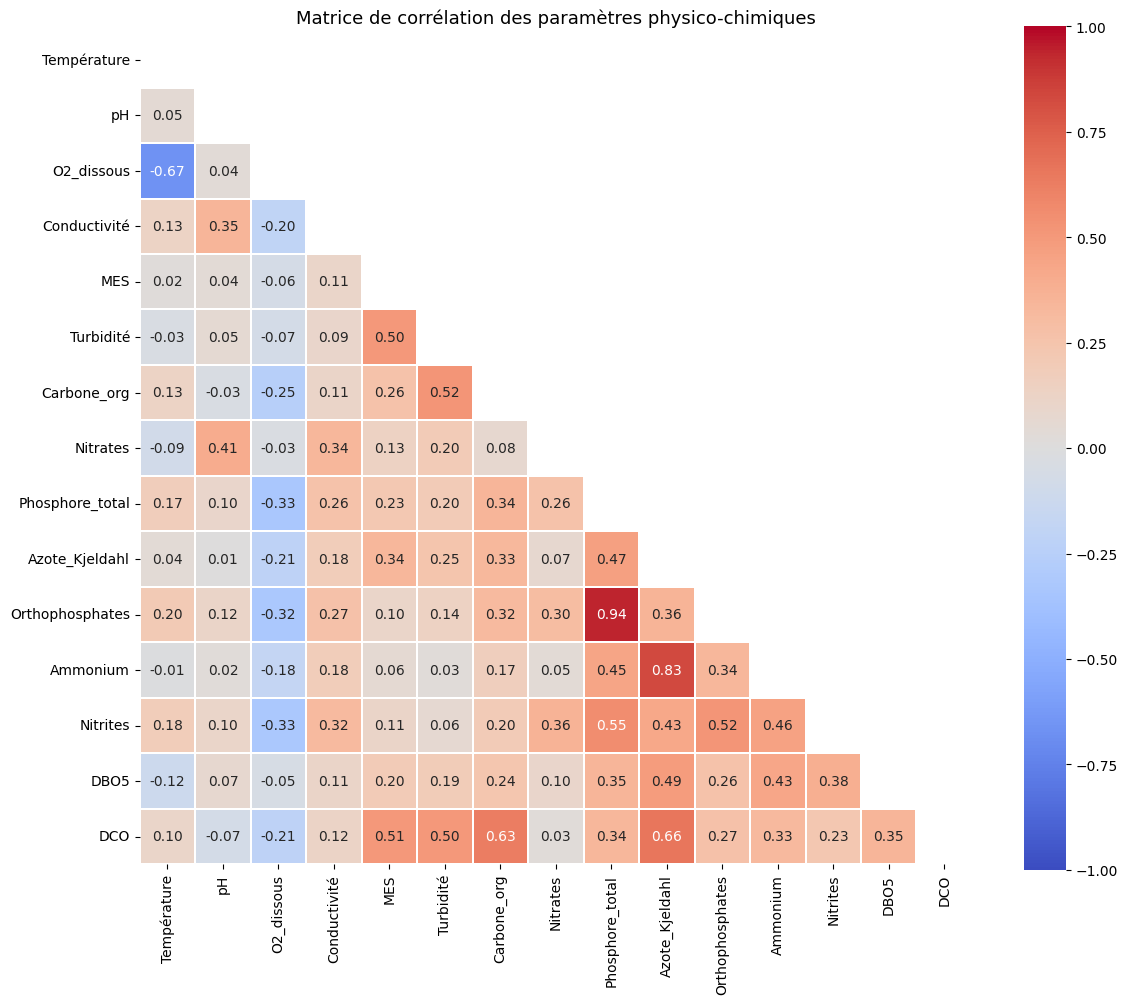

Corrélations notables (|r| > 0.5) :
  Température          ↔ O2_dissous            r = -0.671
  MES                  ↔ Turbidité             r = 0.503
  MES                  ↔ DCO                   r = 0.505
  Turbidité            ↔ Carbone_org           r = 0.518
  Turbidité            ↔ DCO                   r = 0.505
  Carbone_org          ↔ DCO                   r = 0.625
  Phosphore_total      ↔ Orthophosphates       r = 0.944
  Phosphore_total      ↔ Nitrites              r = 0.555
  Azote_Kjeldahl       ↔ Ammonium              r = 0.829
  Azote_Kjeldahl       ↔ DCO                   r = 0.660
  Orthophosphates      ↔ Nitrites              r = 0.523


In [10]:
corr = df_pivot[cols_param].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    ax=ax
)
ax.set_title('Matrice de corrélation des paramètres physico-chimiques', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/tp1_correlation_matrix.png', dpi=120)
plt.show()

print('Corrélations notables (|r| > 0.5) :')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {corr.columns[i]:20s} ↔ {corr.columns[j]:20s}  r = {r:.3f}')

## 6. Gestion des données manquantes

On calcule le taux de renseignement par station et on supprime les stations dont plus de 50 % des paramètres sont manquants sur l'ensemble de l'année.

Pour les stations conservées, les valeurs manquantes résiduelles seront comblées par la moyenne de la station au moment de l'agrégation annuelle de l'étape 2.

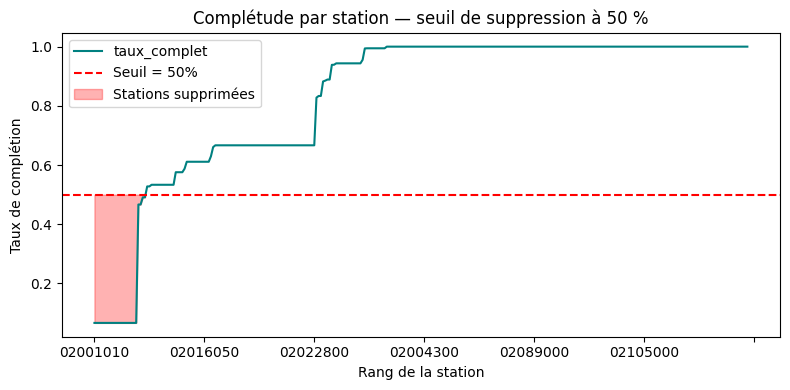

Stations initiales           : 298
Stations supprimées (< 50%) : 24
Stations conservées (≥ 50%) : 274


In [11]:
completude_station = (
    df_pivot.groupby('CdStationMesureEauxSurface')[cols_param]
    .apply(lambda g: g.notna().values.mean())
    .rename('taux_complet')
)

SEUIL = 0.50
stations_ok = completude_station[completude_station >= SEUIL].index
stations_dropped = completude_station[completude_station < SEUIL].index

fig, ax = plt.subplots(figsize=(8, 4))
completude_station.sort_values().plot(kind='line', ax=ax, color='teal')
ax.axhline(SEUIL, color='red', linestyle='--', label=f'Seuil = {SEUIL:.0%}')
ax.fill_between(range(len(completude_station)),
                completude_station.sort_values().values,
                SEUIL,
                where=completude_station.sort_values().values < SEUIL,
                alpha=0.3, color='red', label='Stations supprimées')
ax.set_xlabel('Rang de la station')
ax.set_ylabel('Taux de complétion')
ax.set_title('Complétude par station — seuil de suppression à 50 %')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/tp1_completude_stations.png', dpi=120)
plt.show()

print(f'Stations initiales           : {df_pivot["CdStationMesureEauxSurface"].nunique()}')
print(f'Stations supprimées (< {SEUIL:.0%}) : {len(stations_dropped)}')
print(f'Stations conservées (≥ {SEUIL:.0%}) : {len(stations_ok)}')

In [12]:
df_clean = df_pivot[df_pivot['CdStationMesureEauxSurface'].isin(stations_ok)].copy()

print(f'Tableau nettoyé : {df_clean.shape}')
print(f'  Prélèvements  : {len(df_clean):,}')
print(f'  Stations      : {df_clean["CdStationMesureEauxSurface"].nunique()}')
df_clean.head()

Tableau nettoyé : (3223, 18)
  Prélèvements  : 3,223
  Stations      : 274


,CdStationMesureEauxSurface,LbStationMesureEauxSurface,DatePrel,Température,pH,O2_dissous,Conductivité,MES,Turbidité,Carbone_org,Nitrates,Phosphore_total,Azote_Kjeldahl,Orthophosphates,Ammonium,Nitrites,DBO5,DCO
0,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-01-07,7.0,8.20,12.4,384.0,3.6,3.00,1.9,7.4,0.02,0.6,0.06,0.07,0.03,3.4,6.0
1,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-02-04,5.9,8.10,12.7,378.0,22.0,15.00,2.2,7.4,0.04,0.5,0.09,0.08,0.03,2.1,8.0
2,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-03-04,5.4,8.30,14.6,420.0,2.4,0.99,1.3,7.8,0.02,0.5,0.04,0.08,0.04,1.8,5.0
3,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-04-02,6.7,8.30,11.8,381.0,4.9,2.50,2.7,8.2,0.07,0.5,0.13,0.05,0.05,1.8,5.0
4,02000010,LE GRAND CANAL D'ALSACE A ROSENAU,2013-04-29,10.5,8.25,11.5,385.0,6.7,3.20,1.9,5.2,0.13,0.5,0.14,0.08,0.03,2.1,9.0


## 7. Export

On exporte le tableau nettoyé `etape1_clean_dataset.csv` (station × date × 15 paramètres). Ce fichier est l'entrée de l'étape 2.

In [13]:
df_clean.to_csv('../outputs/tables/etape1_clean_dataset.csv', index=False)
print(f'Export OK → ../outputs/tables/etape1_clean_dataset.csv  ({df_clean.shape})')

Export OK → ../outputs/tables/etape1_clean_dataset.csv  ((3223, 18))
